In [2]:
import os
print(os.getcwd())
!ls

/cephfs/volumes/hpc_data_usr/k24021136/79e7a54a-c7ee-4c01-9056-d9f30f39602d/Ultrasound-project-Git/One_arm_Git
 Clinical_R1_Maternal_Curriculum_Final
 Clinical_R1_Maternal_Curriculum_Final.zip
'Housden created STL and URDF 5'
'JRun (3).ipynb'
 JRun.ipynb
 JRun_deterministic_evaluation.ipynb
 JRunbaseline100k.ipynb
 JRunbaseline20k.ipynb
 Post_processing_j_R1.m
 Ultrasound_Training.ipynb
 evaluation_results
 models
 progressPoseNew_100k.ipynb
 progressPoseRot2_100k.ipynb
 progressPose_100k.ipynb
 progressReward20k.ipynb
 progressStepPenalty_20k.ipynb
 progressnew_1_500k-.ipynb
 progressnew_2_500k--.ipynb
 results
'results zhiqian'
 vec_normalize_stats_maternal_curriculum.pkl


In [3]:
!pip -q install pybullet gymnasium stable-baselines3

In [4]:
# functions nessersary
import numpy as np
import math

# Converts Euler angles ([rx, ry, rz] in deg) to a 3x3 rotation matrix
def EulerToRMat(Euler):

    sx = math.sin(Euler[0]);
    sy = math.sin(Euler[1]);
    sz = math.sin(Euler[2]);
    cx = math.cos(Euler[0]);
    cy = math.cos(Euler[1]);
    cz = math.cos(Euler[2]);

    RMat = np.eye(3);
    RMat[0,0] = cy*cz;
    RMat[0,1] = sx*sy*cz-cx*sz;
    RMat[0,2] = cx*sy*cz+sx*sz;
    RMat[1,0] = cy*sz;
    RMat[1,1] = sx*sy*sz+cx*cz;
    RMat[1,2] = cx*sy*sz-sx*cz;
    RMat[2,0] = -sy;
    RMat[2,1] = sx*cy;
    RMat[2,2] = cx*cy;

    return RMat

# Converts a 3x3 rotation matrix to a quaternion
def RMatToQuat(RMat):

    quat = np.zeros((4,1));

    # abs is to avoid rounding errors in the sqrt - it shouldn't be negative anyway
    quat[0] = 0.5 * math.sqrt(abs(1 + RMat[0,0] + RMat[1,1] + RMat[2,2]));

    if (RMat[2,1] - RMat[1,2] > 0):
        quat[1] = 0.5 * math.sqrt(abs(1 + RMat[0,0] - RMat[1,1] - RMat[2,2]));
    else:
        quat[1] = -0.5 * math.sqrt(abs(1 + RMat[0,0] - RMat[1,1] - RMat[2,2]));


    if (RMat[0,2] - RMat[2,0] > 0):
        quat[2] = 0.5 * math.sqrt(abs(1 - RMat[0,0] + RMat[1,1] - RMat[2,2]));
    else:
        quat[2] = -0.5 * math.sqrt(abs(1 - RMat[0,0] + RMat[1,1] - RMat[2,2]));

    if (RMat[1,0] - RMat[0,1] > 0):
        quat[3] = 0.5 * math.sqrt(abs(1 - RMat[0,0] - RMat[1,1] + RMat[2,2]));
    else:
        quat[3] = -0.5 * math.sqrt(abs(1 - RMat[0,0] - RMat[1,1] + RMat[2,2]));

    return quat

# caclulating difference in Quaternions angles
def quatDiff(q1, q2):

    # Difference: qd = q2 * q1c (q1c = conjugate of q1 = inverse of q1)
    # qd = (w2 + i.x2 + j.y2 + k.z2)(w1 - i.x1 - j.y1 - k.z1)
    # qd = w1.w2 - i.x1.w2 - j.y1.w2 - k.z1.w2 + i.w1.x2 - i^2.x1.x2 - ij.y1.x2 - ik.z1.x2 + j.w1.y2 - ji.x1.y2 - j^2.y1.y2 - jk.z1.y2 + k.w1.z2 - ki.x1.z2 - kj.y1.z2 - k^2.z1.z2
    # qd(1) =  w1.w2 + x1.x2 + y1.y2 + z1.z2
    # qd(2) = -x1.w2 + w1.x2 - z1.y2 + y1.z2
    # qd(3) = -y1.w2 + z1.x2 + w1.y2 - x1.z2
    # qd(4) = -z1.w2 - y1.x2 + x1.y2 + w1.z2

    qd = np.zeros((4,1));
    qd[0] =  q1[0]*q2[0] + q1[1]*q2[1] + q1[2]*q2[2] + q1[3]*q2[3]
    qd[1] = -q1[1]*q2[0] + q1[0]*q2[1] - q1[3]*q2[2] + q1[2]*q2[3]
    qd[2] = -q1[2]*q2[0] + q1[3]*q2[1] + q1[0]*q2[2] - q1[1]*q2[3]
    qd[3] = -q1[3]*q2[0] - q1[2]*q2[1] + q1[1]*q2[2] + q1[0]*q2[3]

    a = 2 * np.arccos(np.float32(qd[0]))

    a = abs(a);

    return a, qd

# normalisation function between -1 and +1
def normalise(x, min_val, max_val):

    # equation for normalisation
    x_n = (2 * (x - min_val) / (max_val - min_val)) - 1

    return x_n

In [5]:
## creating an environment class (child class to gym.Env) for the Ultrasound Robot
import os
import numpy as np
import gymnasium as gym
from gymnasium import spaces
import pybullet as p
import pybullet_utils.bullet_client as bullet_client
import random
import math
import matplotlib.pyplot as plt
import time

class RightArmRobot(gym.Env):
    """
    Custom Environment that follows gym interface.
    """

    # metadata for PyBullet simulation
    metadata = {"render_modes": ["human", "rgb_array"], "simulation_fps": 50}

    def __init__(self, render_mode="human"):

        # calls constructor of parent class gym.Env
        super(RightArmRobot, self).__init__()

        # setting up the render mode for visualisation
        self.render_mode = render_mode

        # initialise PyBullet client ID
        self._physics_client_id = -1

        # initialising the action space as continuous
        # action is angles of all 10 motorised joints
        self.action_space = spaces.Box(low=-1, high=1, shape=(10,), dtype=np.float32)

        # initialising the observation space as continuous
        self.observation_space = spaces.Box(low=-10, high=10, shape=(19,), dtype=np.float32)

        # tolerance for goal completion (position)
        self.pos_tol = 0.02

        # tolerance for goal completion (orientation)
        self.orient_tol = 0.2

        # initialising step number
        self.step_number = 0

        # initialising episode number
        self.episode_number = 0

        # initialise the max step number
        self.max_step_size = 300

        # Phase 2 settings
        # only start orientation tuning when position is already close enough
        self.phase2_pos_gate = 0.03

        # relaxed orientation tolerance for Phase 2
        self.phase2_orient_tol = 1.2

        # small orientation weights so position remains the main task
        self.orientation_weight = 0.05
        self.orientation_progress_weight = 0.5

        # penalty if position gets worse again during orientation tuning
        self.position_drift_penalty = 10.0
        
        # reset function called to properly initialise the environment
        self.reset()

    def reset(self, seed=None, options=None):

        # re-initialisation of environment after truncation / termination / initialisation

        # reset step number
        self.step_number = 0

        # increase the episode number
        self.episode_number += 1

        # calls constructor of parent class gym.Env
        super().reset(seed=seed, options=options)

        # random number generator to provide new target position for the robot
        self.x_target = random.random() * (0.15 - -0.10)
        self.y_target = random.random() * (0.65 - 0.3) + 0.3
        self.z_target = random.random() * (0.35 - 0.15) + 0.15
        self.pos_target = np.array([self.x_target, self.y_target, self.z_target], dtype=np.float32)

        # new orientation target (in Euler angles)
        self.x_euler_t = random.random() * (-0.785398 - -2.35619)
        self.y_euler_t = random.random() * (0.785398 - -0.785398)
        self.z_euler_t = random.random() * (math.pi - -math.pi)
        self.euler_t = np.array([self.x_euler_t, self.y_euler_t, self.z_euler_t])

        # converting the target Euler angles into rotation matrix
        self.Mat_t = EulerToRMat(self.euler_t)

        # converting the target rotation matrix into quaternion
        self.Quat_t = RMatToQuat(self.Mat_t)

        # setup PyBullet client
        if self._physics_client_id < 0:
            if self.render_mode == "human":
                self._bullet_client = bullet_client.BulletClient(connection_mode=p.DIRECT)
            else:
                self._bullet_client = bullet_client.BulletClient()
            self._physics_client_id = self._bullet_client._client

        # setting up PyBullet simulation
        self._bullet_client.resetSimulation()
        self._bullet_client.setGravity(0, 0, -9.8)
        self._bullet_client.setTimeStep(1.0 / self.metadata["simulation_fps"])

        # load robot
        urdf_dir = os.path.join(os.getcwd(), "Housden created STL and URDF 5")
        self._bullet_client.setAdditionalSearchPath(urdf_dir)

        self.RightArmRobot = self._bullet_client.loadURDF(
            os.path.join(urdf_dir, "RightArm.urdf"),
            [0, 0, 0],
            useFixedBase=True
        )

        # check if loading of the robot was successful
        if self.RightArmRobot < 0:
            raise FileNotFoundError("Failed to load RightArm.urdf. Check the file path.")

        # check the number of joints
        self.num_joints = self._bullet_client.getNumJoints(self.RightArmRobot)

        # validate link index
        link_index = 9
        if link_index >= self.num_joints:
            raise IndexError(f"Invalid link index {link_index}. Max index is {self.num_joints - 1}.")

        # get link state
        link_state = self._bullet_client.getLinkState(self.RightArmRobot, link_index)
        if link_state is None:
            raise RuntimeError(f"Failed to get link state for link {link_index}.")

        # get the position of the final link of interest
        link_index = self.num_joints - 1
        link_state = self._bullet_client.getLinkState(self.RightArmRobot, link_index)

        # extracting the x y z position
        self.position = np.array(link_state[0], dtype=np.float32)

        # extracting the orientation as a quaternion
        self.orientation = np.array(link_state[1], dtype=np.float32)

        # calculating initial Euclidean distance from target
        self.Euclid_dist = float(math.dist(self.position, self.pos_target))

        # initialise previous Euclidean distance using the initial distance
        self.prev_Euclid_dist = self.Euclid_dist

        # calculating angular difference from target orientation
        self.Quaternion_diff = quatDiff(self.orientation, self.Quat_t)
        self.Quat_diff_angle = np.asarray(self.Quaternion_diff[0]).item()
        self.Quat_diff_Q = self.Quaternion_diff[1]

        # initialise previous quaternion angle difference
        self.prev_Quat_diff_angle = self.Quat_diff_angle

        # normalising target positions
        self.x_target_n = normalise(self.x_target, -0.10, 0.15)
        self.y_target_n = normalise(self.y_target, 0.3, 0.65)
        self.z_target_n = normalise(self.z_target, 0.15, 0.35)
        self.pos_target_n = np.array([self.x_target_n, self.y_target_n, self.z_target_n], dtype=np.float32)

        # normalising actual positions
        self.x_pos_n = normalise(self.position[0], -0.10, 0.15)
        self.y_pos_n = normalise(self.position[1], 0.3, 0.65)
        self.z_pos_n = normalise(self.position[2], 0.15, 0.35)
        self.pos_n = np.array([self.x_pos_n, self.y_pos_n, self.z_pos_n], dtype=np.float32)

        # observation is:
        # Euclidean distance + quaternion difference + target positions + current positions
        # + current orientation + target orientation
        self.observation = np.concatenate([
            np.array([self.Euclid_dist], dtype=np.float32),
            np.array([self.Quat_diff_Q], dtype=np.float32).flatten(),
            self.pos_target_n.flatten(),
            self.pos_n.flatten(),
            self.orientation.flatten(),
            self.Quat_t.flatten()
        ]).astype(np.float32)

        return self.observation, {}

    def step(self, action):

        # updating the step counter each step
        self.step_number += 1

        # initialise the scaled action variable
        scaled_action = action.copy()

        # scale action by pi
        for i in range(10):
            if i == 0:
                scaled_action[i] = action[i] / 4
            else:
                scaled_action[i] = action[i] * np.pi

        # applying dependent joint constraint
        scaled_action[2] = -scaled_action[1]

        # apply action to robot
        for i in range(10):
            self._bullet_client.setJointMotorControl2(
                self.RightArmRobot,
                i,
                p.POSITION_CONTROL,
                targetPosition=scaled_action[i]
            )

        # update simulation for a few steps
        for _ in range(3):
            self._bullet_client.stepSimulation()

        # get final link state
        link_state = self._bullet_client.getLinkState(self.RightArmRobot, self.num_joints - 1)

        # position and orientation
        self.position = np.array(link_state[0], dtype=np.float32)
        self.orientation = np.array(link_state[1], dtype=np.float32)

        # normalising actual positions
        self.x_pos_n = normalise(self.position[0], -0.10, 0.15)
        self.y_pos_n = normalise(self.position[1], 0.3, 0.65)
        self.z_pos_n = normalise(self.position[2], 0.15, 0.35)
        self.pos_n = np.array([self.x_pos_n, self.y_pos_n, self.z_pos_n], dtype=np.float32)

        # calculating the Euclidean distance
        self.Euclid_dist = float(math.dist(self.position, self.pos_target))

        # calculating the quaternion difference
        self.Quaternion_diff = quatDiff(self.orientation, self.Quat_t)
        self.Quat_diff_angle = np.asarray(self.Quaternion_diff[0]).item()
        self.Quat_diff_Q = self.Quaternion_diff[1]

        # observation
        self.observation = np.concatenate([
            np.array([self.Euclid_dist], dtype=np.float32),
            np.array([self.Quat_diff_Q], dtype=np.float32).flatten(),
            self.pos_target_n.flatten(),
            self.pos_n.flatten(),
            self.orientation.flatten(),
            self.Quat_t.flatten()
        ]).astype(np.float32)

        # new observation stored in variable obs
        obs = self.observation

        # normalise errors
        self.Euclid_dist_n = float(np.clip(self.Euclid_dist / 0.7533, 0, 1))
        self.Quat_diff_angle_n = float(np.clip(self.Quat_diff_angle / (2 * np.pi), 0, 1))

        # progress terms
        progress_pos = float(self.prev_Euclid_dist - self.Euclid_dist)
        progress_rot = float(self.prev_Quat_diff_angle - self.Quat_diff_angle)

        # Phase 2 reward design
        # keep the position task as the main objective
        reward = float(-self.Euclid_dist_n)
        reward += 5.0 * progress_pos

        # only start orientation tuning when the position is already close enough
        in_phase2_zone = (self.Euclid_dist < self.phase2_pos_gate)

        if in_phase2_zone:
            reward += -self.orientation_weight * self.Quat_diff_angle_n
            reward += self.orientation_progress_weight * progress_rot

        # if robot drifts away while tuning orientation, penalise it
        if self.prev_Euclid_dist < self.phase2_pos_gate and self.Euclid_dist >= self.phase2_pos_gate:
            reward -= self.position_drift_penalty

        # update previous values
        self.prev_Euclid_dist = self.Euclid_dist
        self.prev_Quat_diff_angle = self.Quat_diff_angle

        # relaxed Phase 2 success condition
        if self.Euclid_dist < self.pos_tol and self.Quat_diff_angle < self.phase2_orient_tol:
            reward += 100.0
            print("Terminated")
            print("Target position x: ", self.x_target)
            print("Target position y: ", self.y_target)
            print("Target position z: ", self.z_target)
            terminated = True
        else:
            terminated = False

        # truncation criteria
        if self.step_number < self.max_step_size:
            truncated = False
        else:
            truncated = True

        # make sure outputs are Python types
        reward = float(reward)
        terminated = bool(terminated)
        truncated = bool(truncated)

        # updating the info dictionary
        info = {
            "Truncated": truncated,
            "Terminated": terminated,
            "Observations": obs,
            "AngleDiff": self.Quat_diff_angle
        }

        # returning all step variables in a tuple
        return obs, reward, terminated, truncated, info

In [6]:
# defining the custom callback
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
import numpy as np
import matplotlib.pyplot as plt
import json

class CustomCallback(BaseCallback):

    # initialisation of callback
    def __init__(self, run_name="phase2_orient_finetune", total_timesteps=300000, verbose=0):
        super().__init__(verbose)
        self.run_name = run_name
        self.total_timesteps_target = total_timesteps

        # initialisation of variables
        self.timesteps = 0
        self.cum_rewards = 0.0
        self.episode_rewards = []
        self.number_of_episodes = 0
        self.terminations = 0
        self.episode_timesteps = 0
        self.episode_termination = []
        self.final_Euclid_dists = []
        self.change_Euclid_dists = []
        self.final_Quat_diffs = []
        self.change_Quat_diffs = []
        self.mean_rewards = []
        self.std_rewards = []
        self.num_term_per_100 = 0
        self.num_term_per_100_L = []

    def _on_step(self) -> bool:

        # extracting info dictionary
        info = self.locals["infos"][0]

        # extracting the Euclidean distance and quaternion difference
        observations = info.get("Observations")
        Euclid_dist = observations[0]
        Quat_diff = info.get("AngleDiff")

        # checking to see if it is the first timestep of this episode
        if self.episode_timesteps == 0:
            self.initial_Euclid_dist = Euclid_dist
            self.initial_Quat_diff = Quat_diff

        # update timestep counters
        self.timesteps += 1
        self.episode_timesteps += 1

        # print training progress every 1000 timesteps
        if self.timesteps % 1000 == 0:
            print(
                f"[{self.run_name}] "
                f"{self.timesteps}/{self.total_timesteps_target} timesteps | "
                f"episodes: {self.number_of_episodes} | "
                f"terminations: {self.terminations}"
            )

        # get done flag
        if "dones" in self.locals:
            done = self.locals["dones"][0]
        else:
            raise KeyError("Missing 'dones' in self.locals. Check environment compatibility.")

        # see whether the episode has finished
        if done:

            # record episode number
            self.number_of_episodes += 1

            # record episode reward
            self.episode_rewards.append(self.cum_rewards)

            # reset episode counters
            self.cum_rewards = 0.0
            self.episode_timesteps = 0

            # record final Euclidean distance
            self.final_Euclid_dists.append(Euclid_dist)

            # record final quaternion difference
            self.final_Quat_diffs.append(Quat_diff)

            # calculate and record the change in Euclidean distance
            change_Euclid_dist = Euclid_dist - self.initial_Euclid_dist
            self.change_Euclid_dists.append(change_Euclid_dist)

            # calculate and record the change in quaternion difference
            change_Quat_diff = Quat_diff - self.initial_Quat_diff
            self.change_Quat_diffs.append(change_Quat_diff)

            # checking to see if robot reached target
            if info.get("Terminated") is True:
                self.terminations += 1
                self.num_term_per_100 += 1
                self.episode_termination.append(self.number_of_episodes)

        # evaluate every 5000 timesteps
        if self.timesteps % 5000 == 0:
            mean_reward, std_reward = evaluate_policy(
                self.model,
                self.training_env,
                n_eval_episodes=20,
                deterministic=True
            )
            self.mean_rewards.append(mean_reward)
            self.std_rewards.append(std_reward)
            self.num_term_per_100_L.append(self.num_term_per_100)

        # record the reward of the step taken
        reward = float(self.locals["rewards"][0])
        self.cum_rewards += reward

        return True

    def _on_training_end(self) -> None:

        # save arrays
        np.savetxt(f"results/{self.run_name}_reward.txt", np.array(self.episode_rewards))
        np.savetxt(f"results/{self.run_name}_fEuclid.txt", np.array(self.final_Euclid_dists))
        np.savetxt(f"results/{self.run_name}_cEuclid.txt", np.array(self.change_Euclid_dists))
        np.savetxt(f"results/{self.run_name}_fQuat.txt", np.array(self.final_Quat_diffs))
        np.savetxt(f"results/{self.run_name}_cQuat.txt", np.array(self.change_Quat_diffs))
        np.savetxt(f"results/{self.run_name}_mreward.txt", np.array(self.mean_rewards))
        np.savetxt(f"results/{self.run_name}_stdreward.txt", np.array(self.std_rewards))
        np.savetxt(f"results/{self.run_name}_numterm.txt", np.array([self.terminations]))

        # save summary json
        summary = {
            "run_name": self.run_name,
            "num_episodes": self.number_of_episodes,
            "num_terminations": self.terminations,
        }
        with open(f"results/{self.run_name}_summary.json", "w") as f:
            json.dump(summary, f, indent=2)

        # print final summary
        print("Number of episodes:", self.number_of_episodes)
        print("Number of terminations:", self.terminations)

        # plotting graphs
        plt.figure(figsize=(15, 8))

        # rewards vs episode number
        plt.subplot(2, 3, 1)
        plt.plot(self.episode_rewards)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Cumulative Reward")
        plt.title("Cumulative Rewards VS Episode Number")

        # final Euclidean distance vs episode number
        plt.subplot(2, 3, 2)
        plt.plot(self.final_Euclid_dists)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Final Euclidean Distance (m)")
        plt.title("Final Euclidean Distance VS Episode Number")

        # change in Euclidean distance vs episode number
        plt.subplot(2, 3, 3)
        plt.plot(self.change_Euclid_dists)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Change in Euclidean Distance (m)")
        plt.title("Change in Euclidean Distance VS Episode Number")

        # final Quaternion difference vs episode number
        plt.subplot(2, 3, 4)
        plt.plot(self.final_Quat_diffs)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Final Quaternion Difference (rad)")
        plt.title("Final Quaternion Difference VS Episode Number")

        # change in Quaternion Difference vs episode number
        plt.subplot(2, 3, 5)
        plt.plot(self.change_Quat_diffs)
        plt.xlabel("Number of Episodes")
        plt.ylabel("Change in Quaternion Difference (rad)")
        plt.title("Change in Quaternion Difference VS Episode Number")

        plt.tight_layout()
        plt.savefig(f"results/{self.run_name}_plots.png", dpi=300, bbox_inches="tight")
        plt.show()

In [7]:
# wrapping environment
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
import os

# instantating arrayy containing the mean rewards and standard deviation to be computed at the end of each set of 100,000 steps
mean_rewards_arr = np.array(range(10))
std_rewards_arr = np.array(range(10))

# instantiate the robot arm custom environment and wrap with a monitor wrapper
env = Monitor(RightArmRobot())

In [8]:
# checking the environment
# If the environment don't follow the interface, an error will be thrown
check_env(env, warn=True)

In [9]:
import os
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

[progressnew_1000k] 1000/1000000 timesteps | episodes: 3 | terminations: 0
[progressnew_1000k] 2000/1000000 timesteps | episodes: 6 | terminations: 0
[progressnew_1000k] 3000/1000000 timesteps | episodes: 9 | terminations: 0
[progressnew_1000k] 4000/1000000 timesteps | episodes: 13 | terminations: 0
[progressnew_1000k] 5000/1000000 timesteps | episodes: 16 | terminations: 0
[progressnew_1000k] 6000/1000000 timesteps | episodes: 19 | terminations: 0
[progressnew_1000k] 7000/1000000 timesteps | episodes: 22 | terminations: 0
[progressnew_1000k] 8000/1000000 timesteps | episodes: 25 | terminations: 0
[progressnew_1000k] 9000/1000000 timesteps | episodes: 29 | terminations: 0
[progressnew_1000k] 10000/1000000 timesteps | episodes: 32 | terminations: 0
[progressnew_1000k] 11000/1000000 timesteps | episodes: 35 | terminations: 0
[progressnew_1000k] 12000/1000000 timesteps | episodes: 38 | terminations: 0
[progressnew_1000k] 13000/1000000 timesteps | episodes: 41 | terminations: 0
[progressne

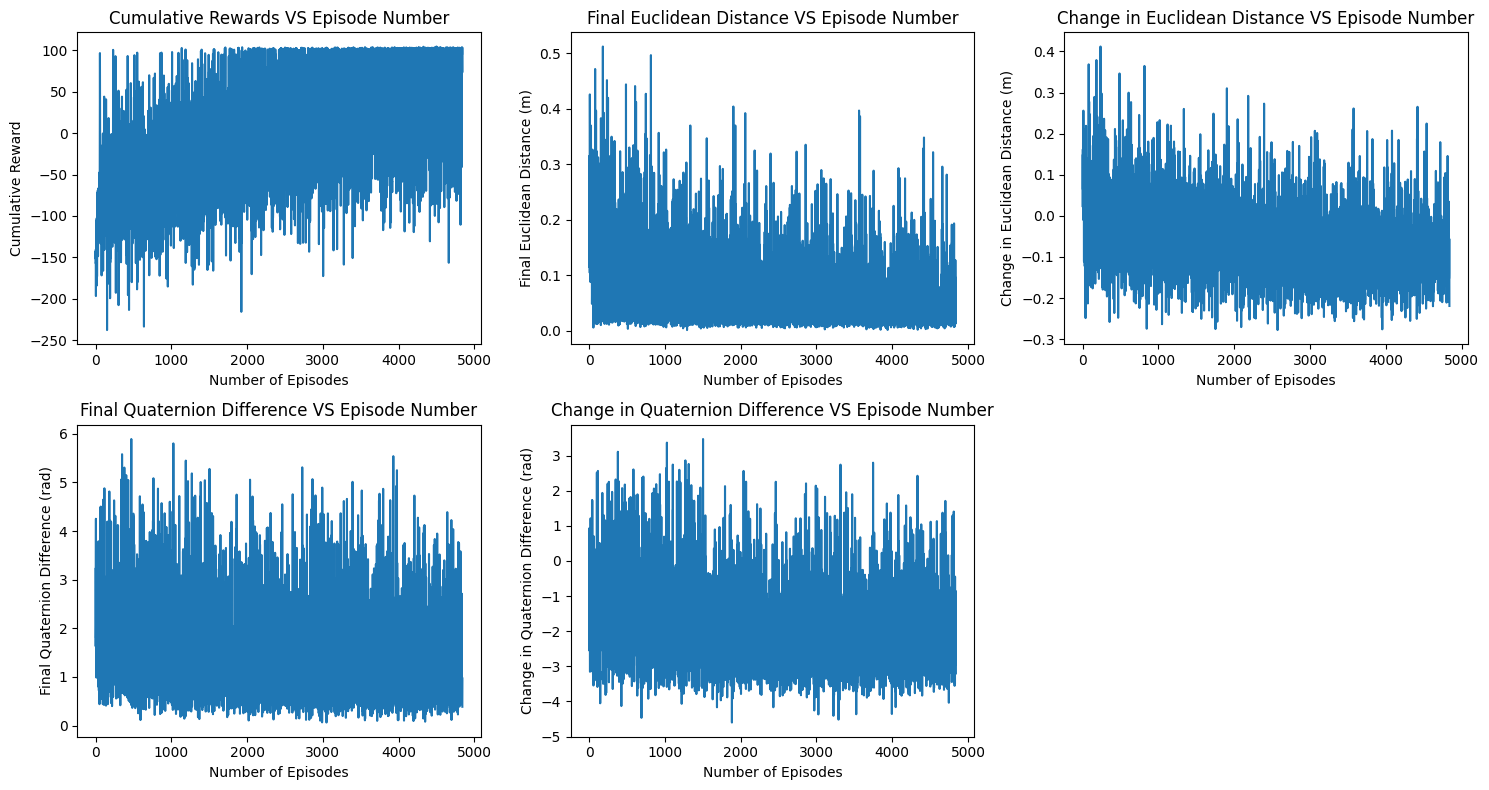

In [10]:
# training Agent
from stable_baselines3 import SAC
import matplotlib.pyplot as plt

TOTAL_TIMESTEPS = 300000

# Instantiate the callback
plotting_callback = CustomCallback(
    run_name="phase2_orient_finetune_300k",
    total_timesteps=TOTAL_TIMESTEPS
)

# load Phase 1 model instead of training from scratch
model = SAC.load("models/progressnew_500k_model", env=env)

# continue training
model.learn(
    total_timesteps=TOTAL_TIMESTEPS,
    callback=plotting_callback,
    log_interval=1,
    reset_num_timesteps=False
)

# save model
model.save("models/phase2_orient_finetune_300k_model")
model.save_replay_buffer("models/phase2_orient_finetune_300k_replaybuffer")

In [18]:
p.disconnect()

In [ ]:
# quick diagnostic - run 100 steps to check for nan and joint limits
env_test = RightArmRobot()

# print joint limits
print("=== Joint Limits ===")
for i in range(env_test.num_joints):
    info = env_test._bullet_client.getJointInfo(env_test.RightArmRobot, i)
    print(f"Joint {i}: lower={info[8]:.3f}, upper={info[9]:.3f}")

# run 100 random steps and check for nan
print("\n=== NaN Check (100 steps) ===")
nan_count = 0
obs, _ = env_test.reset()
for i in range(100):
    action = env_test.action_space.sample()
    obs, reward, terminated, truncated, info = env_test.step(action)
    if np.isnan(info["AngleDiff"]):
        nan_count += 1
        print(f"Step {i}: NaN detected")
    if terminated or truncated:
        obs, _ = env_test.reset()

print(f"\nTotal NaN occurrences: {nan_count}/100")
env_test._bullet_client.disconnect()